# Figure S4 — AUROC vs number of TSSs by ranking (weighting) function

Nested-CV performance marginalized over the five ranking functions used for
TSS selection. Solid lines: the best model using that ranking function at a
given k; dashed lines: the mean AUROC across configurations at that k. All
ranking functions outperform random selection for k < 14,224; at k = all
TSSs the ranking is inert and the curves converge.

**Source data**: `data/fig4_auc_sweep.csv` — the same nested-CV sweep as
Figure 4a/b (written by `export/export_fig4.py`). No pickles, no cluster
paths, no network. Run top to bottom from `src/figures/`.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

WEIGHTING_COLORS = {
    "fold_change": "#56B4E9", "mean_diff": "#E69F00", "p_value": "#009E73",
    "random": "#999999", "weighted": "#D55E00",
}
WEIGHTING_NAME_MAP = {
    "fold_change": "log-FC", "mean_diff": "|Δμ|", "p_value": "MWU",
    "random": "random", "weighted": "weighted",
}

sweep = pd.read_csv("data/fig4_auc_sweep.csv")
summary = (sweep.groupby(["feature", "classifier", "weighting_function", "top_genes"])
           ["auc"].mean().reset_index()
           .rename(columns={"top_genes": "n_genes", "auc": "mean_full_auc"}))
best_auc = float(summary["mean_full_auc"].max())
print(f"{len(summary)} configurations; best mean AUROC = {best_auc:.3f}")

1485 configurations; best mean AUROC = 0.951


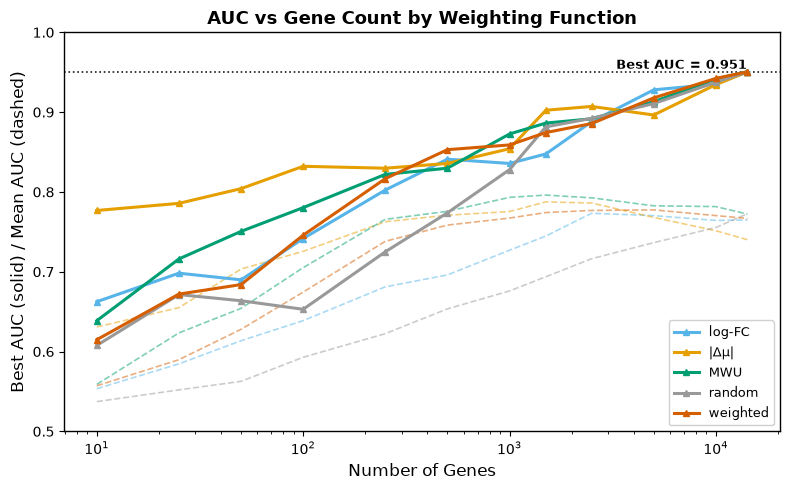

In [2]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

order = (summary.groupby("weighting_function")["mean_full_auc"].max()
         .sort_values(ascending=False).index.tolist())
for w in order:
    sub = summary[summary["weighting_function"] == w]
    agg = sub.groupby("n_genes")["mean_full_auc"].agg(["max", "mean"])
    color = WEIGHTING_COLORS.get(w, "#999999")
    ax.plot(agg.index, agg["max"], marker="^", markersize=5, linewidth=2.2,
            color=color, zorder=3, label=WEIGHTING_NAME_MAP.get(w, w))
    ax.plot(agg.index, agg["mean"], linestyle="--", linewidth=1.2,
            color=color, alpha=0.5, zorder=2)

ax.axhline(best_auc, color="black", linestyle=":", linewidth=1.2, alpha=0.9)
ax.text(ax.get_xlim()[1], best_auc, f"Best AUC = {best_auc:.3f} ",
        ha="right", va="bottom", fontsize=9, fontweight="bold")
ax.set_xscale("log")
ax.set_ylim(0.5, 1.0)
ax.set_xlabel("Number of Genes", fontsize=12)
ax.set_ylabel("Best AUC (solid) / Mean AUC (dashed)", fontsize=12)
ax.set_title("AUC vs Gene Count by Weighting Function", fontsize=13, fontweight="bold")
ax.tick_params(labelsize=10)
ax.legend(loc="lower right", fontsize=9, frameon=True, framealpha=0.92)
for sp in ax.spines.values():
    sp.set_visible(True); sp.set_linewidth(1.0); sp.set_color("black")

plt.tight_layout()
os.makedirs("output", exist_ok=True)
fig.savefig("output/figS4.png", dpi=300, bbox_inches="tight")
fig.savefig("output/figS4.pdf", bbox_inches="tight")
plt.show()

## Checks

The manuscript reports that ranking functions beat random selection for all
k < 14,224 (Mann-Whitney U and mean-difference performing best), and that
all curves meet at k = all TSSs where selection is inert.

In [3]:
piv = (summary.groupby(["weighting_function", "n_genes"])["mean_full_auc"].max()
       .unstack("weighting_function"))
informed = piv.drop(columns="random").max(axis=1)
print("best informed ranking vs random, per k:")
for k in piv.index:
    flag = "informed > random" if informed[k] > piv.loc[k, "random"] else "NOT better"
    print(f"  k={k:>6}: best informed {informed[k]:.3f} vs random {piv.loc[k, 'random']:.3f}  ({flag})")

best informed ranking vs random, per k:
  k=    10: best informed 0.777 vs random 0.608  (informed > random)
  k=    25: best informed 0.786 vs random 0.671  (informed > random)
  k=    50: best informed 0.804 vs random 0.664  (informed > random)
  k=   100: best informed 0.832 vs random 0.653  (informed > random)
  k=   250: best informed 0.830 vs random 0.725  (informed > random)
  k=   500: best informed 0.853 vs random 0.774  (informed > random)
  k=  1000: best informed 0.873 vs random 0.828  (informed > random)
  k=  1500: best informed 0.902 vs random 0.882  (informed > random)
  k=  2500: best informed 0.907 vs random 0.892  (informed > random)
  k=  5000: best informed 0.928 vs random 0.911  (informed > random)
  k= 10000: best informed 0.942 vs random 0.938  (informed > random)
  k= 14224: best informed 0.951 vs random 0.951  (NOT better)
